# Video Dialogue Retrieval — Final Notebook

This notebook implements the pipeline developed so far:

**Video URL → cached video → metadata → audio → VAD → padded speech segments → ASR → word-level timestamped transcript → dialogue retrieval**

The retrieval phase compares three approaches:

1. **Exact phrase search** — baseline
2. **Fuzzy sliding-window search** — scans the transcript and tolerates small ASR errors
3. **Rare-anchor + fuzzy search** — uses an IDF-style word-rarity score to reduce the search space before fuzzy matching

> For a single video transcript, we use **IDF-style word rarity** rather than conventional document-level TF-IDF. Conventional TF-IDF is designed for comparing multiple documents; here our goal is to find distinctive words inside one transcript.

## 0. Configuration

In [1]:
# Install the packages used by the pipeline.
!pip install -q yt-dlp silero-vad faster-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 4.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 48.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 100.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 55.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.5/39.5 MB 50.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 73.2 MB/s eta 0:00:00:00:0100:01


In [2]:
from pathlib import Path
from fractions import Fraction
from collections import Counter
from difflib import SequenceMatcher
import hashlib
import json
import math
import re
import subprocess
import time
import statistics

import pandas as pd
import torch
import yt_dlp

from faster_whisper import WhisperModel
from silero_vad import load_silero_vad, read_audio, get_speech_timestamps

In [3]:
URL = "https://ok.ru/video/248244667877"

MODEL_SIZE = "small"
SAMPLE_RATE = 16000

# VAD / ASR
MERGE_GAP = 0.30
PADDING = 0.25

# Retrieval
FUZZY_EXTRA_CONTEXT = 2
FUZZY_LENGTH_TOLERANCE = 2

# Benchmark
BENCHMARK_RUNS = 5
BENCHMARK_WARMUP = 1

# Cache
CACHE_DIR = Path("/kaggle/working/cache")

VIDEO_DIR = CACHE_DIR / "videos"
METADATA_DIR = CACHE_DIR / "metadata"
AUDIO_DIR = CACHE_DIR / "audio"
VAD_DIR = CACHE_DIR / "vad"
TRANSCRIPT_DIR = CACHE_DIR / "transcripts"
TEMP_AUDIO_DIR = CACHE_DIR / "temp_audio"

for directory in [
    VIDEO_DIR, METADATA_DIR, AUDIO_DIR,
    VAD_DIR, TRANSCRIPT_DIR, TEMP_AUDIO_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


## 1. Video acquisition and metadata

In [4]:
def get_video_id(url: str) -> str:
    return hashlib.sha256(url.encode("utf-8")).hexdigest()[:16]

def get_video_path(video_id: str) -> Path:
    return VIDEO_DIR / f"{video_id}.mp4"

def get_metadata_path(video_id: str) -> Path:
    return METADATA_DIR / f"{video_id}.json"

video_id = get_video_id(URL)
video_path = get_video_path(video_id)

print("Video ID:", video_id)
print("Video path:", video_path)

Video ID: e9f964a2f202b396
Video path: /kaggle/working/cache/videos/e9f964a2f202b396.mp4


In [5]:
def download_video(url: str) -> Path:
    video_id = get_video_id(url)
    output_path = get_video_path(video_id)

    if output_path.exists():
        print("Using cached video:", output_path)
        return output_path

    ydl_opts = {
        "outtmpl": str(output_path),
        "format": "bestvideo+bestaudio/best",
        "merge_output_format": "mp4",
        "noplaylist": True,
    }

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([url])

    return output_path

video_path = download_video(URL)
print("Size:", f"{video_path.stat().st_size / 1024**2:.2f} MB")

[Odnoklassniki] Extracting URL: https://ok.ru/video/248244667877
[Odnoklassniki] 248244667877: Downloading desktop webpage
[Odnoklassniki] 248244667877: Downloading m3u8 information
[info] 248244667877: Downloading 1 format(s): hls-2565
[hlsnative] Downloading m3u8 manifest
[hlsnative] Total fragments: 327
[download] Destination: /kaggle/working/cache/videos/e9f964a2f202b396.mp4
[download] 100% of  997.69MiB in 00:01:27 at 11.44MiB/s                  
[FixupM3u8] Fixing MPEG-TS in MP4 container of "/kaggle/working/cache/videos/e9f964a2f202b396.mp4"
Size: 953.89 MB


In [6]:
def get_metadata(video_path: Path):
    cmd = [
        "ffprobe", "-v", "error",
        "-show_format", "-show_streams",
        "-of", "json", str(video_path)
    ]

    result = subprocess.run(
        cmd, capture_output=True, text=True, check=True
    )
    return json.loads(result.stdout)

metadata = get_metadata(video_path)

video_stream = next(
    stream for stream in metadata["streams"]
    if stream["codec_type"] == "video"
)

audio_stream = next(
    (stream for stream in metadata["streams"]
     if stream["codec_type"] == "audio"),
    None,
)

fps = float(Fraction(video_stream["r_frame_rate"]))

clean_metadata = {
    "duration": float(metadata["format"]["duration"]),
    "fps": fps,
    "fps_raw": video_stream["r_frame_rate"],
    "width": int(video_stream["width"]),
    "height": int(video_stream["height"]),
    "video_codec": video_stream["codec_name"],
    "audio_codec": audio_stream["codec_name"] if audio_stream else None,
    "has_audio": audio_stream is not None,
}

with open(get_metadata_path(video_id), "w") as f:
    json.dump(clean_metadata, f, indent=2)

print(json.dumps(clean_metadata, indent=2))

{
  "duration": 3261.782,
  "fps": 23.976023976023978,
  "fps_raw": "24000/1001",
  "width": 960,
  "height": 720,
  "video_codec": "h264",
  "audio_codec": "aac",
  "has_audio": true
}


## 2. Extract and validate audio

In [7]:
def get_duration(path: Path) -> float:
    cmd = [
        "ffprobe", "-v", "error",
        "-show_entries", "format=duration",
        "-of", "default=noprint_wrappers=1:nokey=1",
        str(path)
    ]
    result = subprocess.run(
        cmd, capture_output=True, text=True, check=True
    )
    return float(result.stdout.strip())

def extract_audio(video_path: Path, audio_path: Path) -> Path:
    if audio_path.exists():
        print("Using cached audio:", audio_path)
        return audio_path

    cmd = [
        "ffmpeg", "-y", "-i", str(video_path),
        "-vn", "-ac", "1", "-ar", str(SAMPLE_RATE),
        "-c:a", "pcm_s16le", str(audio_path)
    ]

    subprocess.run(
        cmd, check=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )
    return audio_path

if not clean_metadata["has_audio"]:
    raise RuntimeError("Video has no audio track; dialogue retrieval cannot continue.")

audio_path = AUDIO_DIR / f"{video_id}.wav"
audio_path = extract_audio(video_path, audio_path)

video_duration = get_duration(video_path)
audio_duration = get_duration(audio_path)

print(f"Video duration : {video_duration:.3f}s")
print(f"Audio duration : {audio_duration:.3f}s")
print(f"Difference     : {abs(video_duration - audio_duration):.3f}s")

Video duration : 3261.782s
Audio duration : 3261.781s
Difference     : 0.001s


## 3. Voice Activity Detection

In [ ]:
vad_model = load_silero_vad()

wav = read_audio(
    str(audio_path),
    sampling_rate=SAMPLE_RATE
)

speech_timestamps = get_speech_timestamps(
    wav,
    vad_model,
    sampling_rate=SAMPLE_RATE
)

print("Raw VAD segments:", len(speech_timestamps))

Raw VAD segments: 633


In [ ]:
def samples_to_seconds(sample_index: int) -> float:
    return sample_index / SAMPLE_RATE

speech_segments = [
    {
        "start": samples_to_seconds(segment["start"]),
        "end": samples_to_seconds(segment["end"])
    }
    for segment in speech_timestamps
]

def merge_speech_segments(segments, max_gap=MERGE_GAP):
    if not segments:
        return []

    merged = [segments[0].copy()]

    for current in segments[1:]:
        previous = merged[-1]
        gap = current["start"] - previous["end"]

        if gap < max_gap:
            previous["end"] = max(previous["end"], current["end"])
        else:
            merged.append(current.copy())

    return merged

merged_segments = merge_speech_segments(speech_segments)

speech_duration = sum(
    segment["end"] - segment["start"]
    for segment in merged_segments
)

print("Original segments:", len(speech_segments))
print("Merged segments  :", len(merged_segments))
print(f"Speech duration  : {speech_duration / 60:.2f} min")
print(f"Speech ratio     : {speech_duration / video_duration:.2%}")

Original segments: 633
Merged segments  : 529
Speech duration  : 20.49 min
Speech ratio     : 37.70%


In [ ]:
def prepare_asr_segments(merged_segments, audio_duration, padding=PADDING):
    asr_segments = []

    for segment in merged_segments:
        speech_start = segment["start"]
        speech_end = segment["end"]

        asr_start = max(0.0, speech_start - padding)
        asr_end = min(audio_duration, speech_end + padding)

        asr_segments.append({
            "speech_start": speech_start,
            "speech_end": speech_end,
            "asr_start": asr_start,
            "asr_end": asr_end
        })

    return asr_segments

asr_segments = prepare_asr_segments(
    merged_segments,
    audio_duration
)

with open(VAD_DIR / f"{video_id}.json", "w") as f:
    json.dump(asr_segments, f, indent=2)

for i, segment in enumerate(asr_segments[:10]):
    print(
        f"{i:03d}: "
        f"speech {segment['speech_start']:.2f} → {segment['speech_end']:.2f} | "
        f"ASR {segment['asr_start']:.2f} → {segment['asr_end']:.2f}"
    )

000: speech 107.94 → 108.61 | ASR 107.69 → 108.86
001: speech 117.70 → 118.81 | ASR 117.45 → 119.06
002: speech 138.43 → 139.13 | ASR 138.18 → 139.38
003: speech 139.87 → 140.54 | ASR 139.62 → 140.79
004: speech 141.38 → 141.92 | ASR 141.13 → 142.17
005: speech 142.91 → 145.57 | ASR 142.66 → 145.82
006: speech 146.08 → 148.64 | ASR 145.83 → 148.89
007: speech 166.98 → 168.09 | ASR 166.73 → 168.34
008: speech 168.48 → 170.49 | ASR 168.23 → 170.74
009: speech 171.14 → 174.97 | ASR 170.89 → 175.22


## 4. Speech-to-text with faster-whisper

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
compute_type = "float16" if device == "cuda" else "int8"

model = WhisperModel(
    MODEL_SIZE,
    device=device,
    compute_type=compute_type
)

print("Model:", MODEL_SIZE)
print("Device:", device)
print("Compute type:", compute_type)

Model: small
Device: cuda
Compute type: float16


In [ ]:
def extract_audio_segment(audio_path, start, end, output_path):
    duration = end - start

    cmd = [
        "ffmpeg", "-y",
        "-ss", str(start),
        "-i", str(audio_path),
        "-t", str(duration),
        "-ac", "1",
        "-ar", str(SAMPLE_RATE),
        "-c:a", "pcm_s16le",
        str(output_path)
    ]

    subprocess.run(
        cmd,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        check=True
    )


def transcribe_vad_segments(audio_path, asr_segments, model):
    transcript = []

    for segment_id, segment in enumerate(asr_segments):
        print(
            f"ASR {segment_id + 1}/{len(asr_segments)}: "
            f"{segment['asr_start']:.2f}s → {segment['asr_end']:.2f}s"
        )

        segment_audio = (
            TEMP_AUDIO_DIR / f"segment_{segment_id:05d}.wav"
        )

        extract_audio_segment(
            audio_path,
            segment["asr_start"],
            segment["asr_end"],
            segment_audio
        )

        whisper_segments, _ = model.transcribe(
            str(segment_audio),
            beam_size=5,
            word_timestamps=True
        )

        for whisper_segment in whisper_segments:
            if not whisper_segment.words:
                continue

            for word in whisper_segment.words:
                transcript.append({
                    "word": word.word.strip(),
                    "start": float(segment["asr_start"] + word.start),
                    "end": float(segment["asr_start"] + word.end),
                    "segment_id": segment_id
                })

    transcript.sort(key=lambda x: x["start"])
    return transcript

In [ ]:
# ASR is the expensive stage, so always reuse the cached transcript if available.
transcript_path = TRANSCRIPT_DIR / f"{video_id}.json"

if transcript_path.exists():
    with open(transcript_path) as f:
        transcript = json.load(f)
    print("Loaded cached transcript:", transcript_path)
else:
    transcript = transcribe_vad_segments(
        audio_path,
        asr_segments,
        model
    )

    with open(transcript_path, "w") as f:
        json.dump(transcript, f, indent=2)

    print("Saved transcript:", transcript_path)

print("Total words:", len(transcript))

if transcript:
    print(
        f"Transcript range: "
        f"{transcript[0]['start']:.2f}s → {transcript[-1]['end']:.2f}s"
    )

ASR 1/529: 107.69s → 108.86s
ASR 2/529: 117.45s → 119.06s
ASR 3/529: 138.18s → 139.38s
ASR 4/529: 139.62s → 140.79s
ASR 5/529: 141.13s → 142.17s
ASR 6/529: 142.66s → 145.82s
ASR 7/529: 145.83s → 148.89s
ASR 8/529: 166.73s → 168.34s
ASR 9/529: 168.23s → 170.74s
ASR 10/529: 170.89s → 175.22s
ASR 11/529: 176.20s → 181.11s
ASR 12/529: 181.35s → 182.68s
ASR 13/529: 182.66s → 185.43s
ASR 14/529: 185.67s → 187.10s
ASR 15/529: 187.34s → 190.87s
ASR 16/529: 197.83s → 199.16s
ASR 17/529: 199.08s → 200.66s
ASR 18/529: 201.51s → 202.78s
ASR 19/529: 203.30s → 218.23s
ASR 20/529: 218.34s → 220.09s
ASR 21/529: 220.23s → 232.12s
ASR 22/529: 233.13s → 234.65s
ASR 23/529: 275.59s → 276.70s
ASR 24/529: 286.25s → 287.64s
ASR 25/529: 287.62s → 288.82s
ASR 26/529: 289.48s → 290.84s
ASR 27/529: 291.27s → 292.38s
ASR 28/529: 293.67s → 297.66s
ASR 29/529: 301.03s → 302.46s
ASR 30/529: 303.62s → 305.43s
ASR 31/529: 306.57s → 310.07s
ASR 32/529: 310.02s → 312.38s
ASR 33/529: 312.49s → 315.99s
ASR 34/529: 316.07s

## 5. Build the searchable transcript index

In [ ]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

for item in transcript:
    item["normalized_word"] = normalize_text(item["word"])

transcript_words = [
    item["normalized_word"]
    for item in transcript
]

print("Indexed words:", len(transcript_words))

Indexed words: 4038


## 6. Method 1 — Exact phrase search

In [ ]:
def exact_phrase_search(transcript_words, target_words):
    matches = []
    target_length = len(target_words)

    if target_length == 0:
        return matches

    for i in range(len(transcript_words) - target_length + 1):
        if transcript_words[i:i + target_length] == target_words:
            matches.append(i)

    return matches


def indices_to_results(transcript, indices, target_length):
    results = []

    for index in indices:
        start_word = transcript[index]
        end_word = transcript[index + target_length - 1]

        results.append({
            "start": float(start_word["start"]),
            "end": float(end_word["end"]),
            "score": 1.0,
            "method": "exact",
            "start_index": index,
            "end_index": index + target_length
        })

    return results

## 7. Method 2 — Fuzzy sliding-window search

In [ ]:
def similarity_score(target_words, candidate_words):
    return SequenceMatcher(
        None,
        " ".join(target_words),
        " ".join(candidate_words)
    ).ratio()


def fuzzy_sliding_window_search(
    transcript_words,
    target_words,
    length_tolerance=FUZZY_LENGTH_TOLERANCE
):
    target_length = len(target_words)

    if target_length == 0:
        return []

    min_length = max(1, target_length - length_tolerance)
    max_length = target_length + length_tolerance

    results = []

    for window_length in range(min_length, max_length + 1):
        for i in range(len(transcript_words) - window_length + 1):
            window = transcript_words[i:i + window_length]

            results.append({
                "start_index": i,
                "end_index": i + window_length,
                "score": similarity_score(target_words, window),
                "method": "fuzzy_sliding_window"
            })

    results.sort(key=lambda x: x["score"], reverse=True)
    return results

## 8. Method 3 — Rare-anchor + fuzzy search

In [24]:
# For one transcript, use an IDF-style rarity score:
# rarity(w) = log(N / (1 + frequency(w)))

word_frequency = Counter(transcript_words)
N = len(transcript_words)

def word_rarity(word):
    frequency = word_frequency.get(word, 0)
    return math.log(N / (1 + frequency))


def choose_anchor(target_words, transcript_words):
    """
    Choose the rarest target word that actually exists
    in the transcript.
    """

    transcript_vocab = set(transcript_words)

    candidates = [
        word
        for word in target_words
        if word in transcript_vocab
    ]

    if not candidates:
        return None

    return max(
        candidates,
        key=word_rarity
    )

def generate_candidate_windows(
    transcript_words,
    target_words,
    anchor,
    extra_context=FUZZY_EXTRA_CONTEXT
):
    anchor_positions = [
        i for i, word in enumerate(transcript_words)
        if word == anchor
    ]

    anchor_offset = target_words.index(anchor)
    target_length = len(target_words)

    candidates = []

    for anchor_index in anchor_positions:
        expected_start = anchor_index - anchor_offset

        start = max(0, expected_start - extra_context)
        end = min(
            len(transcript_words),
            expected_start + target_length + extra_context
        )

        candidates.append({
            "anchor_index": anchor_index,
            "start": start,
            "end": end
        })

    return candidates


def fuzzy_match_region(
    transcript_words,
    target_words,
    start,
    end,
    length_tolerance=FUZZY_LENGTH_TOLERANCE
):
    region = transcript_words[start:end]
    target_length = len(target_words)

    min_length = max(1, target_length - length_tolerance)
    max_length = target_length + length_tolerance

    best = None

    for window_length in range(min_length, max_length + 1):
        for i in range(len(region) - window_length + 1):
            window = region[i:i + window_length]

            result = {
                "start_index": start + i,
                "end_index": start + i + window_length,
                "score": similarity_score(target_words, window),
                "method": "rare_anchor_fuzzy"
            }

            if best is None or result["score"] > best["score"]:
                best = result

    return best


def rare_anchor_fuzzy_search(transcript_words, target_words):

    if not target_words:
        return []

    anchor = choose_anchor(
        target_words,
        transcript_words
    )

    if anchor is None:
        return []

    anchor_positions = [
        i
        for i, word in enumerate(transcript_words)
        if word == anchor
    ]

    candidates = generate_candidate_windows(
        transcript_words,
        target_words,
        anchor,
        anchor_positions
    )

    results = [
        fuzzy_match_candidate(
            transcript_words,
            target_words,
            candidate
        )
        for candidate in candidates
    ]

    return sorted(
        results,
        key=lambda x: x["score"],
        reverse=True
    )

## 9. Convert retrieval results to timestamps

In [ ]:
def add_timestamps(transcript, results):
    output = []

    for result in results:
        start_word = transcript[result["start_index"]]
        end_word = transcript[result["end_index"] - 1]

        item = {
            "start": float(start_word["start"]),
            "end": float(end_word["end"]),
            "score": float(result["score"]),
            "method": result["method"],
            "start_index": result["start_index"],
            "end_index": result["end_index"]
        }

        if "anchor" in result:
            item["anchor"] = result["anchor"]

        output.append(item)

    return output

## 10. Sanity check with the known dialogue

In [ ]:
TARGET = "close the window john"
target_words = normalize_text(TARGET).split()

exact_results = add_timestamps(
    transcript,
    indices_to_results(
        transcript,
        exact_phrase_search(transcript_words, target_words),
        len(target_words)
    )
)

fuzzy_results = add_timestamps(
    transcript,
    fuzzy_sliding_window_search(
        transcript_words,
        target_words
    )
)

rare_results = add_timestamps(
    transcript,
    rare_anchor_fuzzy_search(
        transcript_words,
        target_words
    )
)

print("Target:", TARGET)
print("\nExact:", exact_results[:3])
print("\nFuzzy:", fuzzy_results[:3])
print("\nRare-anchor + fuzzy:", rare_results[:3])

Target: close the window john

Exact: [{'start': 117.448, 'end': 118.588, 'score': 1.0, 'method': 'exact', 'start_index': 3, 'end_index': 7}]

Fuzzy: [{'start': 117.448, 'end': 118.588, 'score': 1.0, 'method': 'fuzzy_sliding_window', 'start_index': 3, 'end_index': 7}, {'start': 117.448, 'end': 138.284, 'score': 0.9333333333333333, 'method': 'fuzzy_sliding_window', 'start_index': 3, 'end_index': 8}, {'start': 108.188, 'end': 118.588, 'score': 0.8936170212765957, 'method': 'fuzzy_sliding_window', 'start_index': 2, 'end_index': 7}]

Rare-anchor + fuzzy: [{'start': 117.448, 'end': 118.588, 'score': 1.0, 'method': 'rare_anchor_fuzzy', 'start_index': 3, 'end_index': 7, 'anchor': 'window'}, {'start': 2454.556, 'end': 2459.852, 'score': 0.7058823529411765, 'method': 'rare_anchor_fuzzy', 'start_index': 2985, 'end_index': 2988, 'anchor': 'window'}]


## 11. Runtime benchmark

In [ ]:
def time_method(method, runs=BENCHMARK_RUNS, warmup=BENCHMARK_WARMUP):
    for _ in range(warmup):
        method()

    times = []

    for _ in range(runs):
        start = time.perf_counter()
        method()
        times.append(time.perf_counter() - start)

    return {
        "mean_ms": statistics.mean(times) * 1000,
        "min_ms": min(times) * 1000,
        "max_ms": max(times) * 1000
    }


# Use an ASR-like spelling error so the three methods are tested on
# a case where exact matching is expected to fail.
BENCHMARK_TARGET = "close the window jon"
benchmark_words = normalize_text(BENCHMARK_TARGET).split()

methods = {
    "Exact search": lambda: exact_phrase_search(
        transcript_words,
        benchmark_words
    ),
    "Fuzzy sliding window": lambda: fuzzy_sliding_window_search(
        transcript_words,
        benchmark_words
    ),
    "Rare anchor + fuzzy": lambda: rare_anchor_fuzzy_search(
        transcript_words,
        benchmark_words
    )
}

benchmark_rows = []

for name, method in methods.items():
    timing = time_method(method)

    benchmark_rows.append({
        "method": name,
        "mean_ms": timing["mean_ms"],
        "min_ms": timing["min_ms"],
        "max_ms": timing["max_ms"]
    })

benchmark_df = (
    pd.DataFrame(benchmark_rows)
    .sort_values("mean_ms")
    .reset_index(drop=True)
)

print("Benchmark target:", BENCHMARK_TARGET)
benchmark_df

Benchmark target: close the window jon


,method,mean_ms,min_ms,max_ms
0,Rare anchor + fuzzy,0.211713,0.189491,0.223402
1,Exact search,0.593234,0.504494,0.784257
2,Fuzzy sliding window,628.434976,623.138298,639.029020


## 12. Quality check with the ASR-like error

In [ ]:
TEST_TARGET = "close the window jon"
test_words = normalize_text(TEST_TARGET).split()

exact_test = add_timestamps(
    transcript,
    indices_to_results(
        transcript,
        exact_phrase_search(transcript_words, test_words),
        len(test_words)
    )
)

fuzzy_test = add_timestamps(
    transcript,
    fuzzy_sliding_window_search(
        transcript_words,
        test_words
    )
)

rare_test = add_timestamps(
    transcript,
    rare_anchor_fuzzy_search(
        transcript_words,
        test_words
    )
)

print("TEST TARGET:", TEST_TARGET)
print("\nExact:", exact_test[:3])
print("\nBest fuzzy:", fuzzy_test[:1])
print("\nBest rare-anchor:", rare_test[:1])

TEST TARGET: close the window jon

Exact: []

Best fuzzy: [{'start': 117.448, 'end': 118.588, 'score': 0.975609756097561, 'method': 'fuzzy_sliding_window', 'start_index': 3, 'end_index': 7}]

Best rare-anchor: []


## 13. Final comparison table

In [ ]:
timing_lookup = {
    row["method"]: row["mean_ms"]
    for row in benchmark_rows
}

quality_rows = []

for name, results in [
    ("Exact search", exact_test),
    ("Fuzzy sliding window", fuzzy_test),
    ("Rare anchor + fuzzy", rare_test)
]:
    best = results[0] if results else None

    quality_rows.append({
        "method": name,
        "mean_time_ms": timing_lookup[name],
        "best_score": best["score"] if best else None,
        "best_start_s": best["start"] if best else None,
        "best_end_s": best["end"] if best else None
    })

comparison_df = (
    pd.DataFrame(quality_rows)
    .sort_values("mean_time_ms")
    .reset_index(drop=True)
)

comparison_df

,method,mean_time_ms,best_score,best_start_s,best_end_s
0,Rare anchor + fuzzy,0.211713,NaN,NaN,NaN
1,Exact search,0.593234,NaN,NaN,NaN
2,Fuzzy sliding window,628.434976,0.97561,117.448,118.588


## Interpretation

The benchmark measures **query-time retrieval**, not the one-time cost of downloading the video, VAD, or ASR.

The expected trade-off is:

- **Exact**: fastest, but fails when the query differs from the transcript.
- **Fuzzy sliding window**: robust to small transcription errors, but scans the complete transcript.
- **Rare-anchor + fuzzy**: uses word rarity to find a small number of candidate regions and then performs fuzzy matching locally.

For a final system, we should not select the winner from one query. The next experiment should use a set of known dialogue queries and measure **top-1 accuracy, recall, score, and runtime** across all three methods.

The next pipeline stage is then **timestamp → frame number → frame extraction**, using the video's FPS already stored in `clean_metadata`.

In [26]:
# ============================================================
# FIXED: Rare Anchor + Fuzzy Search
# ============================================================

def choose_anchor(target_words, transcript_words):
    """
    Select the rarest target word that actually occurs
    in the transcript.
    """

    transcript_vocab = set(transcript_words)

    candidates = [
        word
        for word in target_words
        if word in transcript_vocab
    ]

    if not candidates:
        return None

    return max(
        candidates,
        key=word_rarity
    )


def generate_candidate_windows(
    transcript_words,
    target_words,
    anchor,
    anchor_positions,
    extra_context=2
):
    """
    Generate small candidate regions around every occurrence
    of the selected anchor word.
    """

    candidates = []

    # Position of the anchor inside the target phrase.
    anchor_offset = target_words.index(anchor)

    target_length = len(target_words)

    for anchor_index in anchor_positions:

        # Where the target phrase would start if this
        # occurrence is the correct anchor.
        expected_start = anchor_index - anchor_offset

        start = max(
            0,
            expected_start - extra_context
        )

        end = min(
            len(transcript_words),
            expected_start + target_length + extra_context
        )

        candidates.append({
            "anchor_index": anchor_index,
            "start": start,
            "end": end
        })

    return candidates


def fuzzy_match_candidate(
    transcript_words,
    target_words,
    candidate
):
    """
    Fuzzy-match the target against a small candidate region.
    """

    target_length = len(target_words)

    region = transcript_words[
        candidate["start"]:
        candidate["end"]
    ]

    best = {
        "start_index": None,
        "end_index": None,
        "score": -1.0,
        "method": "rare_anchor_fuzzy"
    }

    min_length = max(
        1,
        target_length - 2
    )

    max_length = target_length + 2

    for window_length in range(
        min_length,
        max_length + 1
    ):

        if window_length > len(region):
            continue

        for i in range(
            len(region) - window_length + 1
        ):

            window = region[
                i:i + window_length
            ]

            score = text_similarity(
                " ".join(target_words),
                " ".join(window)
            )

            if score > best["score"]:

                best = {
                    "start_index":
                        candidate["start"] + i,

                    "end_index":
                        candidate["start"] +
                        i +
                        window_length,

                    "score": score,

                    "method":
                        "rare_anchor_fuzzy"
                }

    return best


def rare_anchor_fuzzy_search(
    transcript_words,
    target_words
):
    """
    Search using the rarest target word that exists
    in the transcript, then perform fuzzy matching
    only around that anchor.
    """

    if not target_words:
        return []

    # ------------------------------------------------
    # 1. Select valid anchor
    # ------------------------------------------------

    anchor = choose_anchor(
        target_words,
        transcript_words
    )

    if anchor is None:
        return []

    # ------------------------------------------------
    # 2. Find anchor occurrences
    # ------------------------------------------------

    anchor_positions = [
        i
        for i, word in enumerate(transcript_words)
        if word == anchor
    ]

    # ------------------------------------------------
    # 3. Generate candidate regions
    # ------------------------------------------------

    candidates = generate_candidate_windows(
        transcript_words,
        target_words,
        anchor,
        anchor_positions
    )

    # ------------------------------------------------
    # 4. Fuzzy-match each candidate
    # ------------------------------------------------

    results = []

    for candidate in candidates:

        result = fuzzy_match_candidate(
            transcript_words,
            target_words,
            candidate
        )

        # Keep the anchor for debugging/
        # evaluation purposes.
        result["anchor"] = anchor

        results.append(result)

    # ------------------------------------------------
    # 5. Rank candidates
    # ------------------------------------------------

    return sorted(
        results,
        key=lambda x: x["score"],
        reverse=True
    )

In [29]:
from difflib import SequenceMatcher

def text_similarity(a, b):
    """
    Returns a similarity score between 0 and 1.
    1.0 = identical
    0.0 = completely different
    """
    return SequenceMatcher(None, a, b).ratio()

In [30]:
TEST_TARGET = "close the window jon"

test_words = normalize_text(
    TEST_TARGET
).split()

print("TEST TARGET:")
print(TEST_TARGET)

print("\nTarget words:")
print(test_words)

print("\nSelected anchor:")

anchor = choose_anchor(
    test_words,
    transcript_words
)

print(anchor)

print("\nAnchor positions:")

anchor_positions = [
    i
    for i, word in enumerate(transcript_words)
    if word == anchor
]

print(anchor_positions)

print("\nExact:")
print(
    exact_phrase_search(
        transcript_words,
        test_words
    )
)

print("\nRare-anchor + fuzzy:")

anchor_results = rare_anchor_fuzzy_search(
    transcript_words,
    test_words
)

for result in anchor_results[:5]:
    print(result)

TEST TARGET:
close the window jon

Target words:
['close', 'the', 'window', 'jon']

Selected anchor:
window

Anchor positions:
[5, 2986]

Exact:
[]

Rare-anchor + fuzzy:
{'start_index': 3, 'end_index': 7, 'score': 0.975609756097561, 'method': 'rare_anchor_fuzzy', 'anchor': 'window'}
{'start_index': 2985, 'end_index': 2987, 'score': 0.6666666666666666, 'method': 'rare_anchor_fuzzy', 'anchor': 'window'}


In [31]:
# ============================================================
# STEP 6.1 — Timestamp → Frame Number
# ============================================================

def timestamp_to_frame(timestamp, fps):
    """
    Convert a timestamp in seconds to the corresponding
    video frame number.

    Frame numbering is 0-based.
    """
    return int(round(timestamp * fps))


# Use the best retrieval result
best_result = anchor_results[0]

start_time = best_result["start"] if "start" in best_result else \
             transcript[best_result["start_index"]]["start"]

end_time = best_result["end"] if "end" in best_result else \
           transcript[best_result["end_index"] - 1]["end"]

start_frame = timestamp_to_frame(start_time, fps)
end_frame = timestamp_to_frame(end_time, fps)

print("Dialogue:")
print(f"  {start_time:.3f}s → {end_time:.3f}s")

print("\nFPS:")
print(f"  {fps}")

print("\nFrame range:")
print(f"  {start_frame} → {end_frame}")

Dialogue:
  117.448s → 118.588s

FPS:
  23.976023976023978

Frame range:
  2816 → 2843


In [32]:
# ============================================================
# STEP 6.2 — Extract Frame
# ============================================================

FRAME_DIR = CACHE_DIR / "frames"
FRAME_DIR.mkdir(parents=True, exist_ok=True)

frame_path = FRAME_DIR / (
    f"{video_id}_frame_{start_frame}.jpg"
)

def extract_frame(
    video_path,
    timestamp,
    output_path
):
    """
    Extract the video frame at approximately `timestamp`.
    """

    cmd = [
        "ffmpeg",
        "-y",

        # Seek accurately by placing -ss after -i.
        "-i", str(video_path),

        "-ss", f"{timestamp:.6f}",

        "-frames:v", "1",

        "-q:v", "2",

        str(output_path)
    ]

    subprocess.run(
        cmd,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        check=True
    )

    return output_path


extract_frame(
    video_path,
    start_time,
    frame_path
)

print("Frame saved to:")
print(frame_path)

Frame saved to:
/kaggle/working/cache/frames/e9f964a2f202b396_frame_2816.jpg


Frame number: 2816
Timestamp: 117.448s


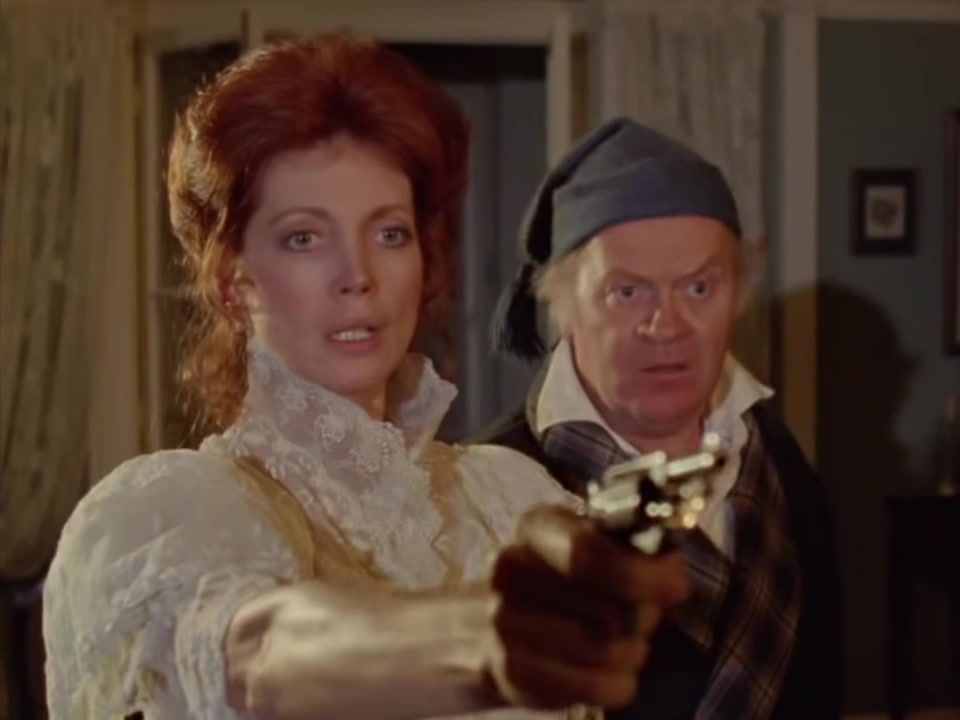

In [33]:
from IPython.display import display
from PIL import Image

image = Image.open(frame_path)

print(f"Frame number: {start_frame}")
print(f"Timestamp: {start_time:.3f}s")

display(image)

In [34]:
# ============================================================
# STEP 6.4 — Extract Frames Around Dialogue
# ============================================================

test_offsets = [
    -0.5,
    0.0,
    0.5,
    end_time - start_time
]

test_frames = []

for offset in test_offsets:

    timestamp = max(
        0,
        start_time + offset
    )

    frame_number = timestamp_to_frame(
        timestamp,
        fps
    )

    output_path = FRAME_DIR / (
        f"{video_id}_frame_{frame_number}.jpg"
    )

    extract_frame(
        video_path,
        timestamp,
        output_path
    )

    test_frames.append({
        "timestamp": timestamp,
        "frame_number": frame_number,
        "path": output_path
    })

for item in test_frames:
    print(
        f"{item['timestamp']:.3f}s "
        f"→ frame {item['frame_number']}"
    )

116.948s → frame 2804
117.448s → frame 2816
117.948s → frame 2828
118.588s → frame 2843



Timestamp: 116.948s | Frame: 2804


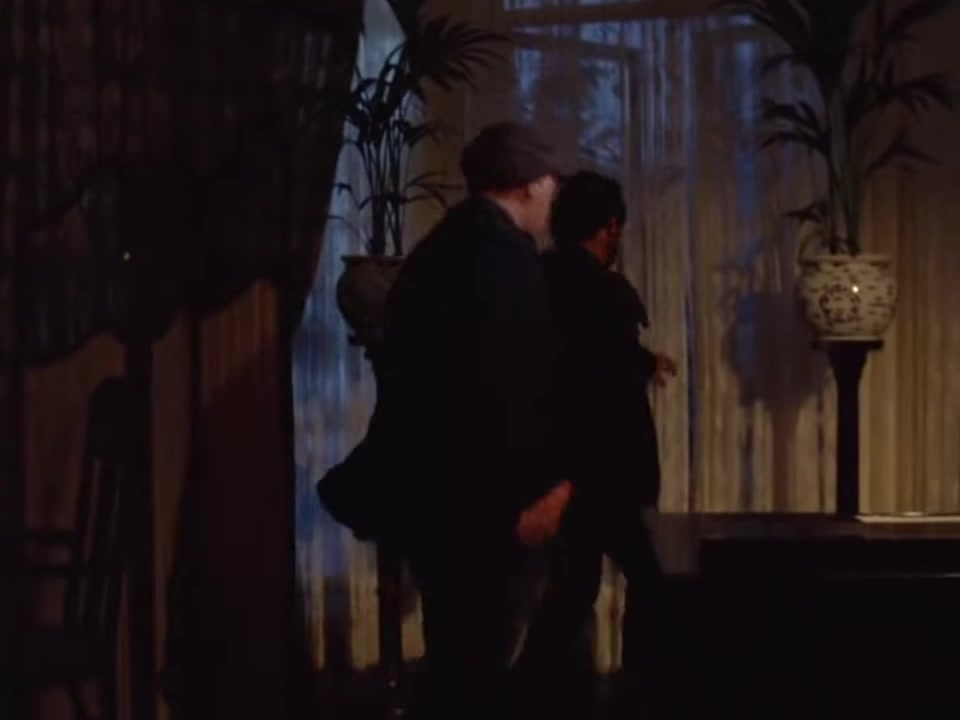


Timestamp: 117.448s | Frame: 2816


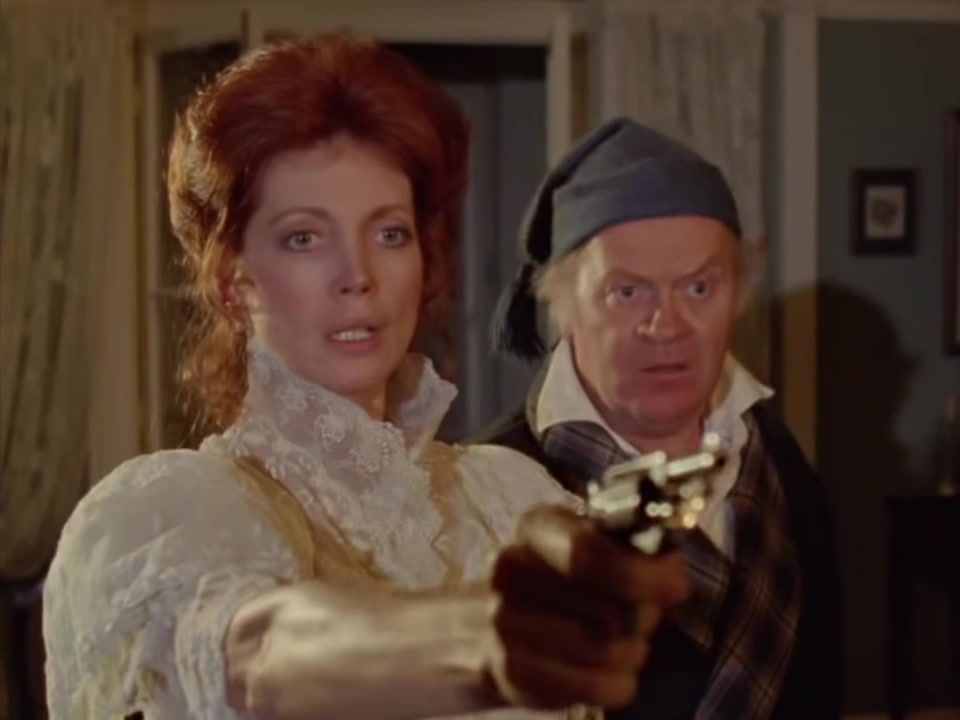


Timestamp: 117.948s | Frame: 2828


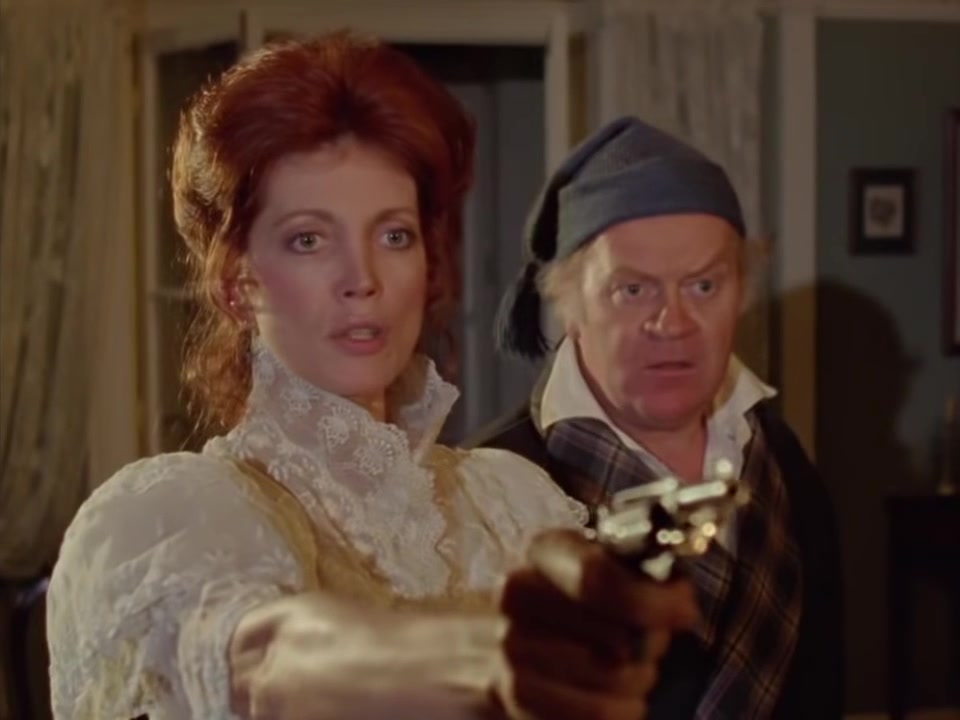


Timestamp: 118.588s | Frame: 2843


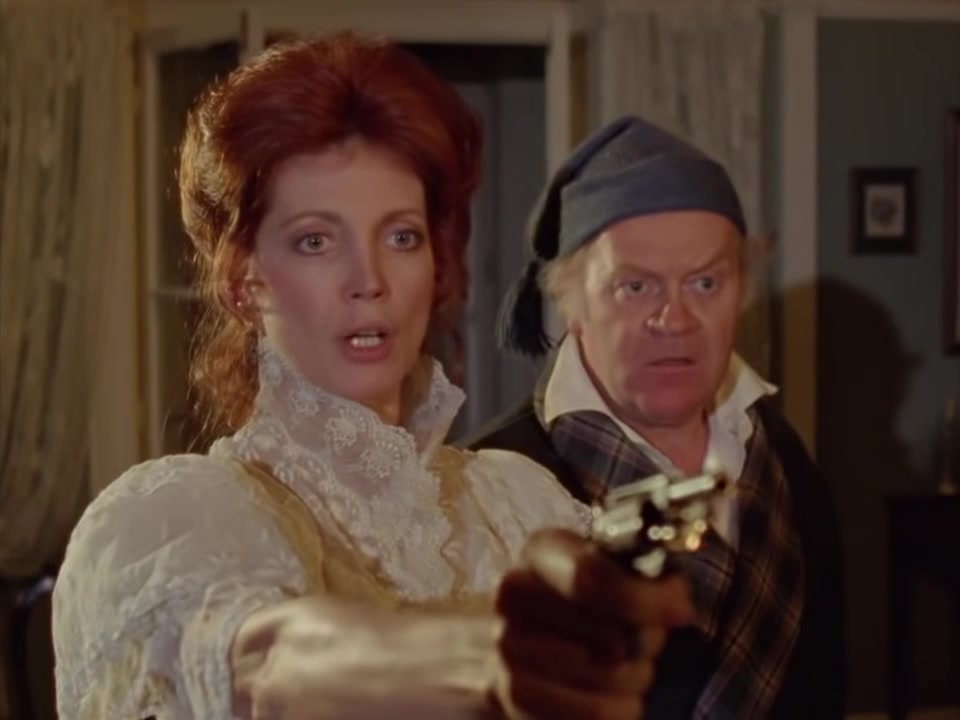

In [35]:
for item in test_frames:

    print(
        f"\nTimestamp: {item['timestamp']:.3f}s"
        f" | Frame: {item['frame_number']}"
    )

    display(Image.open(item["path"]))

In [36]:
# ============================================================
# STEP 7 — STRUCTURED OUTPUT
# ============================================================

final_result = {
    "video": {
        "url": VIDEO_URL,
        "duration_seconds": video_duration,
        "fps": fps,
        "resolution": {
            "width": clean_metadata["width"],
            "height": clean_metadata["height"]
        }
    },

    "query": {
        "dialogue": TEST_TARGET,
        "method": "rare_anchor_fuzzy"
    },

    "match": {
        "text": " ".join(
            transcript[i]["word"]
            for i in range(
                best_result["start_index"],
                best_result["end_index"]
            )
        ),

        "start_timestamp": float(start_time),
        "end_timestamp": float(end_time),

        "start_frame": int(start_frame),
        "end_frame": int(end_frame),

        "score": float(best_result["score"]),

        "anchor": best_result.get("anchor")
    },

    "frame": {
        "timestamp": float(start_time),
        "frame_number": int(start_frame),
        "path": str(frame_path)
    }
}

print(json.dumps(final_result, indent=2))

NameError: name 'VIDEO_URL' is not defined

In [ ]:
RESULT_DIR = CACHE_DIR / "results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

result_path = RESULT_DIR / (
    f"{video_id}_dialogue_result.json"
)

with open(result_path, "w") as f:
    json.dump(final_result, f, indent=2)

print("Result saved:")
print(result_path)

In [42]:
# ============================================================
# FINAL END-TO-END FUNCTION
# ============================================================

def find_dialogue(video_url, target_dialogue, method="rare_anchor_fuzzy", top_k=5):
    """
    Find a target dialogue inside a video and return structured
    timestamp + frame information.

    Parameters
    ----------
    video_url : str
        URL of the video.

    target_dialogue : str
        Dialogue to search for.

    method : str
        "exact", "fuzzy", or "rare_anchor_fuzzy"

    top_k : int
        Number of candidate matches to return.

    Returns
    -------
    dict
        Structured retrieval result.
    """

    # --------------------------------------------------------
    # 1. Video identification
    # --------------------------------------------------------

    video_id = get_video_id(video_url)
    video_path = VIDEO_DIR / f"{video_id}.mp4"

    # --------------------------------------------------------
    # 2. Download video if necessary
    # --------------------------------------------------------

    if not video_path.exists():

        try:
            import yt_dlp
        except ImportError:
            raise RuntimeError(
                "yt-dlp is not installed. "
                "Install it or place the video in the Kaggle input."
            )

        video_path = download_video_with_ytdlp(video_url)

    # --------------------------------------------------------
    # 3. Metadata
    # --------------------------------------------------------

    metadata_path = METADATA_DIR / f"{video_id}.json"

    if metadata_path.exists():

        with open(metadata_path) as f:
            clean_metadata = json.load(f)

    else:

        metadata = get_metadata(video_path)

        video_stream = next(
            s for s in metadata["streams"]
            if s["codec_type"] == "video"
        )

        audio_stream = next(
            (
                s for s in metadata["streams"]
                if s["codec_type"] == "audio"
            ),
            None
        )

        fps = float(
            Fraction(video_stream["r_frame_rate"])
        )

        clean_metadata = {
            "duration": float(
                metadata["format"]["duration"]
            ),

            "fps": fps,

            "fps_raw":
                video_stream["r_frame_rate"],

            "width":
                int(video_stream["width"]),

            "height":
                int(video_stream["height"]),

            "video_codec":
                video_stream["codec_name"],

            "audio_codec":
                audio_stream["codec_name"]
                if audio_stream else None,

            "has_audio":
                audio_stream is not None
        }

        with open(metadata_path, "w") as f:
            json.dump(
                clean_metadata,
                f,
                indent=2
            )

    fps = clean_metadata["fps"]
    video_duration = clean_metadata["duration"]

    # --------------------------------------------------------
    # 4. Audio
    # --------------------------------------------------------

    if not clean_metadata["has_audio"]:
        raise RuntimeError(
            "Video has no audio track."
        )

    audio_path = AUDIO_DIR / f"{video_id}.wav"

    if not audio_path.exists():

        extract_audio(
            video_path,
            audio_path
        )

    audio_duration = get_duration(
        audio_path
    )

    # --------------------------------------------------------
    # 5. VAD
    # --------------------------------------------------------

    vad_path = VAD_DIR / f"{video_id}.json"

    if vad_path.exists():

        with open(vad_path) as f:
            asr_segments = json.load(f)

    else:

        wav = read_audio(
            str(audio_path),
            sampling_rate=16000
        )

        speech_timestamps = get_speech_timestamps(
            wav,
            vad_model,
            sampling_rate=16000
        )

        speech_segments = [
            {
                "start":
                    samples_to_seconds(s["start"]),

                "end":
                    samples_to_seconds(s["end"])
            }
            for s in speech_timestamps
        ]

        merged_segments = merge_speech_segments(
            speech_segments
        )

        asr_segments = prepare_asr_segments(
            merged_segments,
            audio_duration
        )

        with open(vad_path, "w") as f:
            json.dump(
                asr_segments,
                f,
                indent=2
            )

    # --------------------------------------------------------
    # 6. ASR / Transcript
    # --------------------------------------------------------

    transcript_path = (
        TRANSCRIPT_DIR /
        f"{video_id}.json"
    )

    if transcript_path.exists():

        with open(transcript_path) as f:
            transcript = json.load(f)

    else:

        transcript = transcribe_vad_segments(
            audio_path,
            asr_segments,
            model
        )

        with open(transcript_path, "w") as f:
            json.dump(
                transcript,
                f,
                indent=2
            )

    if not transcript:
        raise RuntimeError(
            "No speech was detected in the video."
        )

    # --------------------------------------------------------
    # 7. Prepare transcript
    # --------------------------------------------------------

    for item in transcript:

        item["normalized_word"] = normalize_text(
            item["word"]
        )

    transcript_words = [
        item["normalized_word"]
        for item in transcript
    ]

    # --------------------------------------------------------
    # 8. Search dialogue
    # --------------------------------------------------------

    target_words = normalize_text(
        target_dialogue
    ).split()

    if not target_words:
        raise ValueError(
            "Target dialogue is empty."
        )

    if method == "exact":

        raw_results = exact_phrase_search(
            transcript_words,
            target_words
        )

        results = []

        for index in raw_results:

            results.append({
                "start_index": index,
                "end_index":
                    index + len(target_words),

                "score": 1.0,

                "method": "exact"
            })

    elif method == "fuzzy":

        results = fuzzy_sliding_search(
            transcript_words,
            target_words
        )

    elif method == "rare_anchor_fuzzy":

        results = rare_anchor_fuzzy_search(
            transcript_words,
            target_words
        )

    else:

        raise ValueError(
            f"Unknown search method: {method}"
        )

    if not results:

        return {
            "success": False,

            "video_url": video_url,

            "query": target_dialogue,

            "method": method,

            "message":
                "Dialogue was not found."
        }

    # --------------------------------------------------------
    # 9. Convert search results → timestamps + frames
    # --------------------------------------------------------

    matches = []

    FRAME_DIR = CACHE_DIR / "frames"
    FRAME_DIR.mkdir(
        parents=True,
        exist_ok=True
    )

    for rank, result in enumerate(
        results[:top_k],
        start=1
    ):

        start_index = result["start_index"]
        end_index = result["end_index"]

        start_time = float(
            transcript[start_index]["start"]
        )

        end_time = float(
            transcript[end_index - 1]["end"]
        )

        start_frame = timestamp_to_frame(
            start_time,
            fps
        )

        end_frame = timestamp_to_frame(
            end_time,
            fps
        )

        frame_path = (
            FRAME_DIR /
            f"{video_id}_frame_{start_frame}.jpg"
        )

        if not frame_path.exists():

            extract_frame(
                video_path,
                start_time,
                frame_path
            )

        matched_text = " ".join(
            transcript[i]["word"]
            for i in range(
                start_index,
                end_index
            )
        )

        matches.append({

            "rank": rank,

            "matched_text":
                matched_text,

            "start_timestamp":
                start_time,

            "end_timestamp":
                end_time,

            "start_frame":
                start_frame,

            "end_frame":
                end_frame,

            "score":
                float(result["score"]),

            "frame_path":
                str(frame_path),

            "anchor":
                result.get("anchor")
        })

    # --------------------------------------------------------
    # 10. Final structured output
    # --------------------------------------------------------

    final_result = {

        "success": True,

        "video": {

            "url":
                video_url,

            "duration_seconds":
                video_duration,

            "fps":
                fps,

            "resolution": {

                "width":
                    clean_metadata["width"],

                "height":
                    clean_metadata["height"]
            }
        },

        "query": {

            "dialogue":
                target_dialogue,

            "normalized":
                " ".join(target_words),

            "method":
                method
        },

        "matches":
            matches
    }

# --------------------------------------------------------
# 11. Save result
# --------------------------------------------------------

    RESULT_DIR = CACHE_DIR / "results"
    RESULT_DIR.mkdir(
        parents=True,
        exist_ok=True
    )
    
    result_path = (
        RESULT_DIR /
        f"{video_id}_result.json"
    )
    with open(result_path, "w") as f:
        json.dump(
            final_result,
            f,
            indent=2
        )

    final_result["result_file"] = str(
        result_path
    )

    return final_result

In [43]:
result = find_dialogue(
    "https://ok.ru/video/248244667877",
    "My mind rebels at stagnation"
)

In [44]:
print(json.dumps(result, indent=2))

{
  "success": true,
  "video": {
    "url": "https://ok.ru/video/248244667877",
    "duration_seconds": 3261.782,
    "fps": 23.976023976023978,
    "resolution": {
      "width": 960,
      "height": 720
    }
  },
  "query": {
    "dialogue": "My mind rebels at stagnation",
    "normalized": "my mind rebels at stagnation",
    "method": "rare_anchor_fuzzy"
  },
  "matches": [
    {
      "rank": 1,
      "matched_text": "My mind rebels at stagnation.",
      "start_timestamp": 325.0,
      "end_timestamp": 327.66,
      "start_frame": 7792,
      "end_frame": 7856,
      "score": 1.0,
      "frame_path": "/kaggle/working/cache/frames/e9f964a2f202b396_frame_7792.jpg",
      "anchor": "rebels"
    }
  ],
  "result_file": "/kaggle/working/cache/results/e9f964a2f202b396_result.json"
}


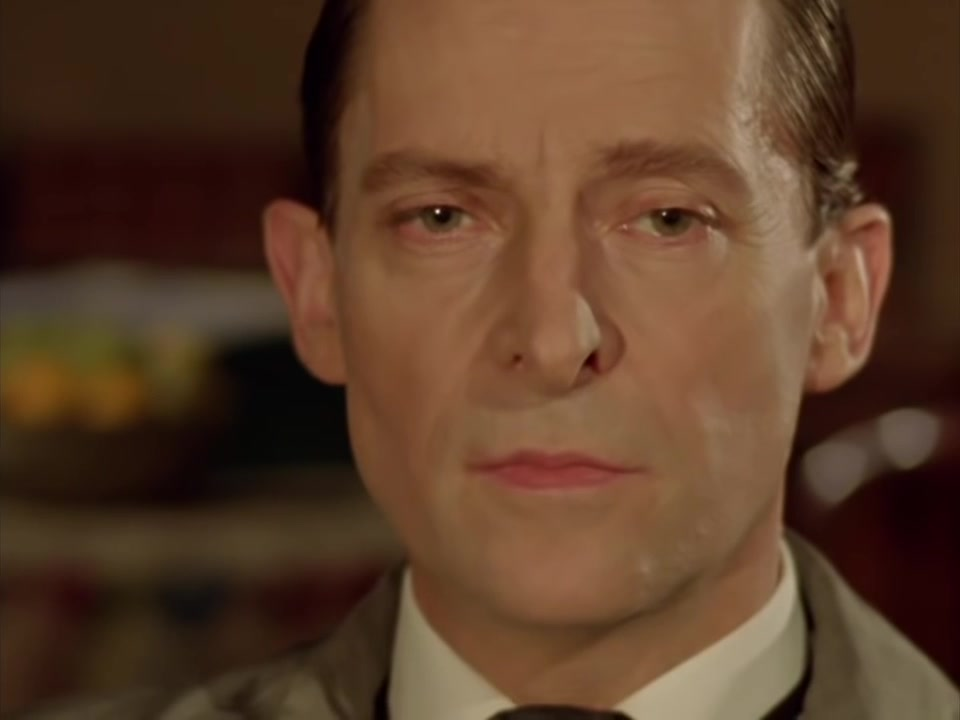

In [45]:
display(Image.open(result["matches"][0]["frame_path"]))